# Tester_branch에서 최종 모델 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''
wine_df = pd.DataFrame(wine.data, columns= wine.feature_names)


wine_df['target'] = wine.target


X = wine_df.drop(columns = 'target')
y = wine_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

In [2]:
''' 코드를 작성해주세요 '''
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

data_model = DecisionTreeClassifier(random_state=42)
data_parameters = {'criterion':['gini','entropy'], 'max_depth':[2,3,4,5], 'min_samples_split':[2,10],'min_samples_leaf':[1,2,4]}
data_grid = GridSearchCV(estimator= data_model, param_grid= data_parameters, scoring = 'accuracy', cv = 5)
data_grid.fit(X_train, y_train)

data_best_model = data_grid.best_estimator_
data_pred = data_best_model.predict(X_test)

data_accuracy = accuracy_score(y_test, data_pred)

print('='*20, 'DT 성능 확인', '='*20)
print('DT accuracy:', data_accuracy)
print(classification_report(y_test, data_pred))

==================== DT 성능 확인 ====================
DT accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [3]:
''' 코드를 작성해주세요 '''
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

data_xgb_model = XGBClassifier(random_state= 42, eval_metric = 'mlogloss')
data_xgb_parameters = {'max_depth':[3,5,7,9,15], 'learning_rate': [0.1, 0.01, 0.001], 'n_estimators':[50, 100, 200, 300]}
xgb_grid = GridSearchCV(estimator= data_xgb_model, param_grid=data_xgb_parameters, scoring = 'accuracy', cv = 5)
xgb_grid.fit(X_train, y_train)
xgb_best_model = xgb_grid.best_estimator_
xgb_pred = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print('='*20, 'XGB 성능 확인', '='*20)
print('XGB accuracy:', xgb_accuracy)
print(classification_report(y_test, xgb_pred))

==================== XGB 성능 확인 ====================
XGB accuracy: 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

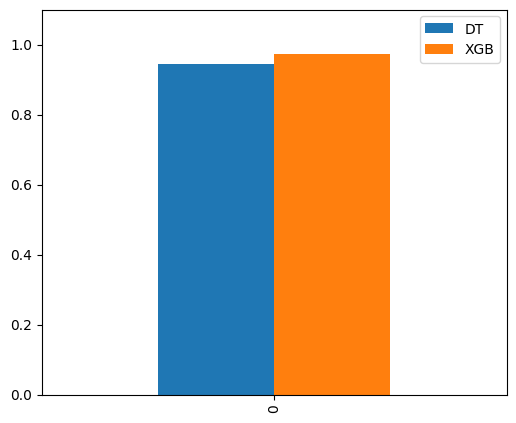

In [7]:
''' 코드를 작성해주세요 '''

performance_df = pd.DataFrame({'DT': [data_accuracy], 'XGB':[xgb_accuracy]})

performance_df.plot(kind = "bar", figsize = (6,5))

plt.ylim(0, 1.1)
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">